# Palette Extraction

In [1]:
from PIL import Image
from scipy.ndimage import sobel
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

import oklab


def extract_palette(image_np, n_colours=5, contrast_weight_factor=3.0, downsampling_factor=4):
    image_np_oklab = oklab.np_srgb_to_oklab(image_np)
    height, width, _ = image_np_oklab.shape

    # Compute luminance gradient to weight high-contrast regions more strongly.
    luminance = image_np_oklab[:, :, 0].astype(np.float32)
    luminance_image = Image.fromarray(luminance)
    low_res_luminance = luminance_image.resize((width // downsampling_factor, height // downsampling_factor), Image.Resampling.LANCZOS)

    low_grad_x = sobel(np.array(low_res_luminance), axis=1)
    low_grad_y = sobel(np.array(low_res_luminance), axis=0)
    low_gradient_magnitude = np.sqrt(low_grad_x ** 2 + low_grad_y ** 2)

    grad_image_low = Image.fromarray(low_gradient_magnitude.astype(np.float32))
    upscaled_gradient = grad_image_low.resize((width, height), Image.Resampling.BILINEAR)
    gradient_magnitude = np.array(upscaled_gradient)

    scaler = MinMaxScaler(feature_range=(1, 1 + contrast_weight_factor))
    weights = scaler.fit_transform(gradient_magnitude.reshape(-1, 1)).flatten()

    pixels = image_np_oklab.reshape(-1, 3)
    kmeans = KMeans(n_clusters=n_colours, random_state=42, n_init=10).fit(pixels, sample_weight=weights)
    palette_oklab = kmeans.cluster_centers_

    palette_rgb = np.array([oklab.oklab_to_srgb(c) for c in palette_oklab], dtype=np.uint8)
    return palette_rgb


def show_palette(palette_rgb, k):
    fig, ax = plt.subplots(1, 1, figsize=(k, 1), dpi=80)

    for i, color_rgb in enumerate(palette_rgb):
        normalized_color = color_rgb / 255.0
        rect = patches.Rectangle((i, 0), 1, 1, facecolor=normalized_color)
        ax.add_patch(rect)

    ax.set_xlim(0, k)
    ax.set_ylim(0, 1)
    ax.axis('off')

    plt.show()

Palette RGB values:
[[112   8  46]
 [213 189 191]
 [195  74 123]
 [ 67   3  21]
 [154  22  76]]


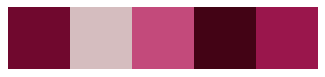

In [ ]:
image_path = './picture_of_the_year.jpg'
n_colours = 5

image = Image.open(image_path).convert('RGB')
image_np = np.array(image)

palette = extract_palette(image_np, n_colours=n_colours)
print('Palette RGB values:')
print(palette)

show_palette(palette, n_colours)